<a href="https://colab.research.google.com/github/luggiestar/CRMS/blob/matser/1_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Linear Regression

## Objective
This notebook aims to introduce you to [scikit-learn](https://scikit-learn.org/stable/), a powerful library for predictive data analysis. We will use simple linear regression to predict crop yields based on sunlight measurements.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

Download the dataset

In [2]:
!wget https://raw.githubusercontent.com/driesmarzougui/tanzania-datasets-24/main/datasets/crop_yield.csv

--2024-08-20 11:45:23--  https://raw.githubusercontent.com/driesmarzougui/tanzania-datasets-24/main/datasets/crop_yield.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 77333 (76K) [text/plain]
Saving to: ‘crop_yield.csv’

crop_yield.csv      100%[===================>]  75.52K  --.-KB/s    in 0.02s   

2024-08-20 11:45:23 (3.46 MB/s) - ‘crop_yield.csv’ saved [77333/77333]



## Load the data
We will start by loading the data. This dataset contains samples of soil moisture, temperature, sunlight measurements, whether or not fertilizer was used and the resulting crop yield.

In [3]:
df = pd.read_csv("./crop_yield.csv")
df.head()

,soil_moisture,temperature,sunlight,fertilizer,crop_yield,crop_health
0,21.236204,18.702659,6.093645,0,61.640664,0
1,38.521429,25.838019,5.975830,0,73.390534,0
2,31.959818,32.458917,11.250037,0,69.202957,0
3,27.959755,29.644498,5.996370,1,72.787156,0
4,14.680559,31.131223,6.175598,0,54.173168,0


To make things a bit easier, we can store the the different columns as variables.

In [23]:
# Independent variables (features)
soil_moisture = df["soil_moisture"].to_numpy(dtype=float)
temperature = df["temperature"].to_numpy(dtype=float)
sunlight = df["sunlight"].to_numpy(dtype=float)
fertilizer = df["fertilizer"].to_numpy(dtype=int)

# Dependent variable (feature
crop_yield = df["crop_yield"].to_numpy(dtype=float)


## Predicting crop yield based on sunlight

Let's try to predict the crop yield using the sunlight feature only.
In the following code cell, first try to visualise their relationship using a scatter plot. Put the sunlight measurements on the X-axis, and the crop yield on the Y-axis.

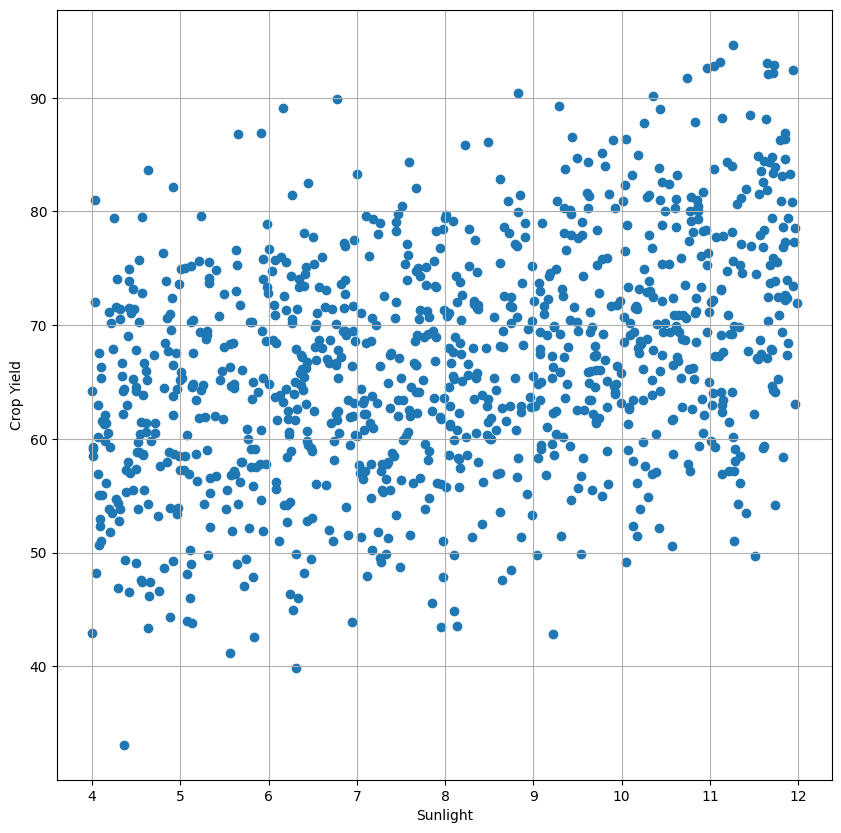

In [13]:
# TODO: scatter plot of sunlight and crop yield measurements.
plt.figure(figsize=(10, 10))
plt.scatter(sunlight, crop_yield)
plt.xlabel("Sunlight")
plt.ylabel("Crop Yield")
plt.grid()
plt.show()

Although there is some noise, we can notice a linear relationship between the two. Consequently, simple linear regression seems as a good option!

Let's start by splitting our data into a training and test set.

In [14]:
x, y = sunlight, crop_yield

# sklearn expects input and output values to be of the shape (num samples, num features), so let's reshape x and y from (num samples) to (num_samples, 1)
x, y = x.reshape(-1, 1), y.reshape(-1, 1)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"x_train: {x_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"x_test: {x_test.shape}")
print(f"y_test: {y_test.shape}")

x_train: (800, 1)
y_train: (800, 1)
x_test: (200, 1)
y_test: (200, 1)


Now we can easily use sklearn's [LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) class to easily fit a linear model to this data.

In [15]:
linear_regressor = LinearRegression()
linear_regressor.fit(x_train, y_train)

LinearRegression()

To predict crop yield using this fitted model, we just need to do the following:

In [16]:
y_train_pred = linear_regressor.predict(x_train)
y_test_pred = linear_regressor.predict(x_test)

That was easy! Time to evaluate this model. Let's start with a qualitative evaluation by visualising the results. We'll first visualise how the model has fitted itself to the training data by creating a scatter plot that shows (x_train, y_train) samples in blue and (x_train, y_train_pred) samples in red.


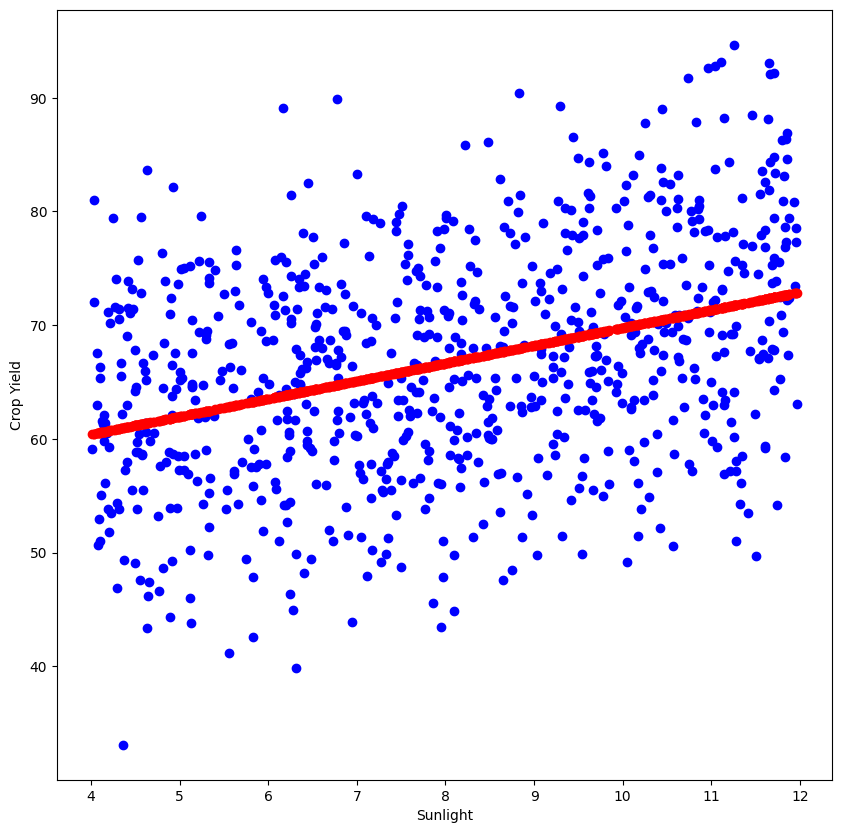

In [21]:
# Todo: scatter plot with training data
plt.figure(figsize=(10, 10))
plt.scatter(x_train, y_train, color="blue")
plt.scatter(x_train, y_train_pred, color="red")
plt.xlabel("Sunlight")
plt.ylabel("Crop Yield")
plt.show()

Great! Now do the same for the test set. This allows us to empirically evaluate if our model is usable for data not seen during training, and thus whether it can generalise and be actually useful.

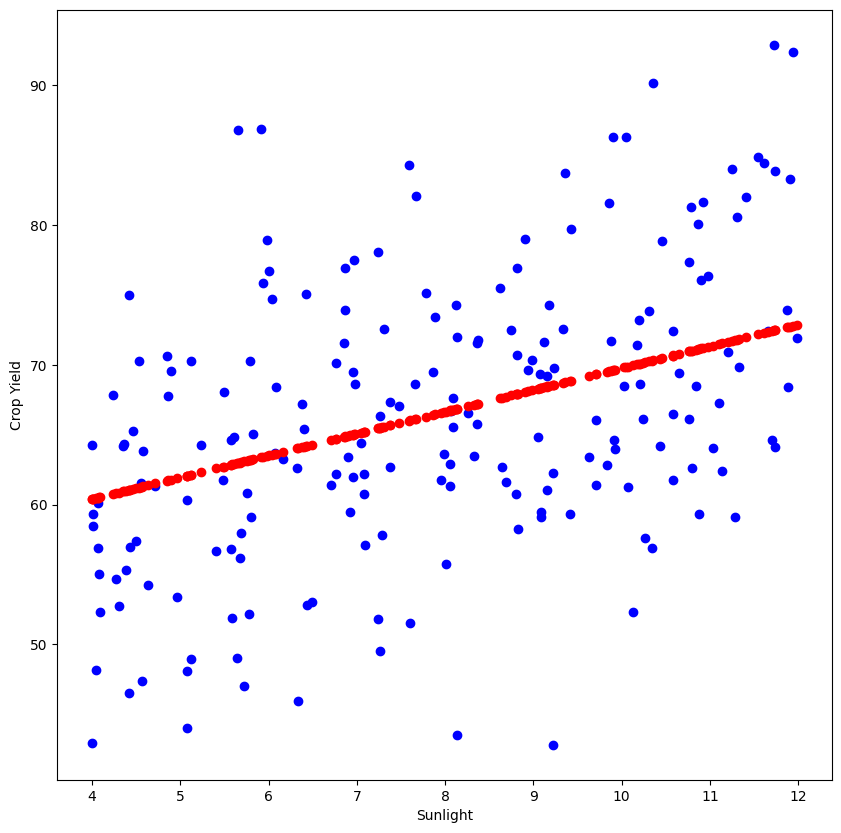

In [22]:
# Todo: scatter plot with test data
plt.figure(figsize=(10, 10))
plt.scatter(x_test, y_test, color="blue")
plt.scatter(x_test, y_test_pred, color="red")
plt.xlabel("Sunlight")
plt.ylabel("Crop Yield")
plt.show()

It seems like the model successfully matches the linear pattern present in the data.

While visual evaluations like this are quite handy as a sanity check and to possibly debug our model if it does not work, quantitative metrics are important to be able to compare different models or setups with one another. Let's calculate some!

In [ ]:
# Evaluate the model
mse = mean_squared_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

Finally, we can take a look at the fitted parameters, i.e. the slope and intercept. These can give us insights into the relationship between sunlight and crop yield.

In [ ]:
slope, intercept = linear_regressor.coef_[0, 0], linear_regressor.intercept_[0]
print(f"Slope:      {slope}")
print(f"Intercept:  {intercept}")